4.340547707101759
3.9720191629604895
5.083768622144738
3.6755101942246764
5.116257529033696
3.385338535189986
2.3163816722721666
0.3440450287132783
0.0
0.0


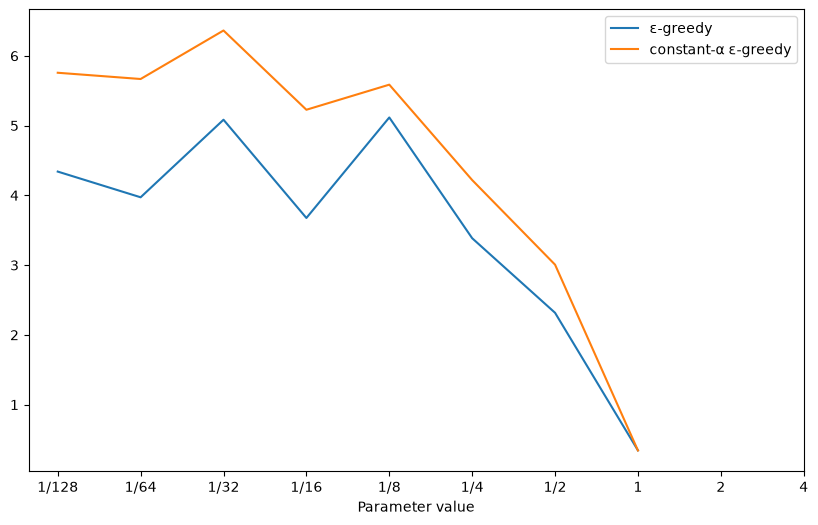

In [1]:
# Exercise 2.11: non-stationary parameter study
# Create a parameter study between ε-greedy, constant α-greedy, UCB, gradient bandit, and optimistic greedy methods on a non-stationary 10-armed bandit problem.
# Plot average reward using the last 100,000 steps of a 200,000 step run.
# Result:
import numpy as np
import matplotlib.pyplot as plt
import random

def bandit(action, true_rewards):
    reward = random.gauss(true_rewards[action],1)
    return reward

def egreedy(true_rewards, value_estimates, action_chosen, epsilon, steps):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = np.where(value_estimates == greediest_value)[0]
            action = np.random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
    return reward
            

def agreedy(true_rewards, value_estimates, action_chosen, epsilon, step_size, steps):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = np.where(value_estimates == greediest_value)[0]
            action = np.random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    return reward

# def ucb(true_rewards, value_estimates, action_chosen, epsilon, steps, rewards):
#     for step in range(1, steps + 1):
#         for e in val_est[ucb]:
            
#         reward = bandit(action,true_rewards)
#         action_chosen[action] += 1
#         value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
#     return reward
            

def main():
    # initialize parameters in the parameter study
    gradient_alpha = epsilon = confidence = optimistic_initial = 1/128
    # initialize static parameters and numpy arrays
    steps = 200000
    runs = 20
    step_size_alpha = 0.1
    methods = ['egreedy', 'agreedy', 'ucb', 'optigreedy', 'gradient']
    parameter_reward = {m: [] for m in methods}
    # test range of parameters
    for i in range(10):
        avg_rewards = {m: np.zeros(steps//2) for m in methods}
        
        # simulate runs
        for run in range(1, runs + 1):
            
            # initialize start of run variables
            true_rewards  = np.zeros(10)
             # note that though "optigreedy" is in val_est, it's not used
            optigreedy_val_est = [optimistic_initial] * 10
            val_est = {m: np.zeros(10) for m in methods}
            action_count = {m: np.zeros(10) for m in methods}
            run_rewards = {m: [] for m in methods}
        
            # simulate one run for each method
            for step in range(1,steps + 1):
                if epsilon <= 1:
                    egreedy_reward = egreedy(true_rewards, val_est['egreedy'], action_count['egreedy'], epsilon, 1)
                    agreedy_reward = agreedy(true_rewards, val_est['agreedy'], action_count['agreedy'], epsilon, step_size_alpha, 1)

                if step > 100000:
                     run_rewards['egreedy'].append(egreedy_reward)
                     run_rewards['agreedy'].append(agreedy_reward)
                # true rewards' random walk
                true_rewards += np.random.normal(0, 0.01, 10)
            if epsilon <= 1:
                avg_rewards['egreedy'] += run_rewards['egreedy']
                avg_rewards['agreedy'] += run_rewards['agreedy']

            # agreedy_avg_rewards += agreedy_run_rewards
            # ucb_avg_rewards += egreedy_run_rewards
            # optigreedy_avg_rewards += egreedy_run_rewards
            # gradient_avg_rewards += egreedy_run_rewards
        
        # get average rewards over runs
        for m in methods:
            avg_rewards[m] /= runs

        # get average reward of rewards
        avg_reward = {m: np.mean(avg_rewards[m]) for m in methods}
        
        if epsilon <= 1:
            parameter_reward['egreedy'].append(avg_reward['egreedy'])
            parameter_reward['agreedy'].append(avg_reward['agreedy'])

        else:
            parameter_reward['egreedy'].append(np.nan)           
            parameter_reward['agreedy'].append(np.nan)

        print(avg_reward['egreedy'])
        # agreedy_parameter_reward.append(agreedy_avg_reward)
        # ucb_parameter_reward.append(ucb_avg_reward)
        # optigreedy_parameter_reward.append(optigreedy_avg_reward)
        # gradient_parameter_reward.append(gradient_avg_reward)
        
        # multiply all params by 2
        gradient_alpha, epsilon, confidence, optimistic_initial = [x * 2 for x in (gradient_alpha, epsilon, confidence, optimistic_initial)]

    # graphs
    params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4] 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(params, parameter_reward['egreedy'], label='ε-greedy')
    ax.plot(params, parameter_reward['agreedy'], label='constant-α ε-greedy')

    #ax.plot(params, avg_rewards_ucb, label='UCB
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Parameter value')
    ax.set_xticks(params)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'1/{int(1/x)}' if x < 1 else str(int(x))))
    ax.legend()
    plt.show()

main()